In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import mcts
import tm
import heuristic
import task_generators
import numpy as np
import training
import torch
from torch import nn
from torch import optim
from time import time
import random
import matplotlib.pyplot as plt

In [3]:
tm_state_base = tm.TMState()
heuristic_model = heuristic.HeuristicModel(tm_state_base)

In [ ]:
training_samples = training.generate_training_samples(heuristic_model.rollout_function, task_generators.copy_task_generator)

Generating data for target: tensor([1., 1., 0., 1., 1.], dtype=torch.float64)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001EECF6C9B20>>
Traceback (most recent call last):
  File "c:\Users\JonasPK\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [24]:
training.save_training_data(training_samples, "0_epochs_copy")

In [5]:
training_samples = torch.load("./training_data/0_epochs_copy")
print(training_samples)

[(tensor([0., 3.]), tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])), (tensor([0., 2.]), tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])), (tensor([0., 1.]), tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [6]:
def train_heuristic(heuristic, training_data, epochs = 1000):
    losses = [None for _ in range(epochs)]
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.SGD(heuristic.parameters(), lr=0.5)
    start_time = time()

    for i in range(epochs):
        running_loss = 0
        training_samples = 0

        for state, action in training_data:
            optimizer.zero_grad()
            output_action = heuristic(state)
            loss = loss_function(output_action, action.to(torch.float))
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            training_samples += 1
        
        losses[i] = running_loss/training_samples
        print(f"Epoch {i}/{epochs} - Loss {running_loss/training_samples} - Time {time() - start_time}s")
    return losses

In [7]:
losses = train_heuristic(heuristic_model.model, training_samples)

Epoch 0/1000 - Loss 4.852043612249966 - Time 0.16997361183166504s
Epoch 1/1000 - Loss 4.851975005248497 - Time 0.3109755516052246s
Epoch 2/1000 - Loss 4.851905247260785 - Time 0.4605259895324707s
Epoch 3/1000 - Loss 4.851834757574673 - Time 0.6005256175994873s
Epoch 4/1000 - Loss 4.851763108680988 - Time 0.7410345077514648s
Epoch 5/1000 - Loss 4.85169007038248 - Time 0.8805396556854248s
Epoch 6/1000 - Loss 4.851614853431439 - Time 1.0235517024993896s
Epoch 7/1000 - Loss 4.8515370878679995 - Time 1.1620588302612305s
Epoch 8/1000 - Loss 4.851456428396291 - Time 1.3055660724639893s
Epoch 9/1000 - Loss 4.851372932565623 - Time 1.444579839706421s
Epoch 10/1000 - Loss 4.851285901562921 - Time 1.5860893726348877s
Epoch 11/1000 - Loss 4.851194759895062 - Time 1.7260994911193848s
Epoch 12/1000 - Loss 4.851099351356769 - Time 1.8676049709320068s
Epoch 13/1000 - Loss 4.850998681167076 - Time 2.006110906600952s
Epoch 14/1000 - Loss 4.850891195494553 - Time 2.148122549057007s
Epoch 15/1000 - Loss 4

In [8]:
print(losses)

[4.852043612249966, 4.851975005248497, 4.851905247260785, 4.851834757574673, 4.851763108680988, 4.85169007038248, 4.851614853431439, 4.8515370878679995, 4.851456428396291, 4.851372932565623, 4.851285901562921, 4.851194759895062, 4.851099351356769, 4.850998681167076, 4.850891195494553, 4.850775792680937, 4.850651033993425, 4.850515612240495, 4.850367324105624, 4.850202478211502, 4.850017333852834, 4.849806226533035, 4.849561280217664, 4.849270508207124, 4.84891495211371, 4.848463050250349, 4.847855017102998, 4.8469565901263, 4.8453825753310635, 4.841243801445796, 4.817403974204228, 4.796713664613921, 4.796565343593729, 4.796511608978798, 4.796483635902405, 4.796466457432714, 4.796455001008922, 4.7964466193626665, 4.796440391704954, 4.79643559044805, 4.7964316853161515, 4.796428573542628, 4.7964259468275925, 4.796423727068408, 4.796421844383766, 4.796420183675043, 4.796418806602215, 4.796417548738677, 4.796416455301745, 4.796415464631442, 4.796414547953113, 4.796413750484072, 4.796413039

Text(0, 0.5, 'Training Loss')

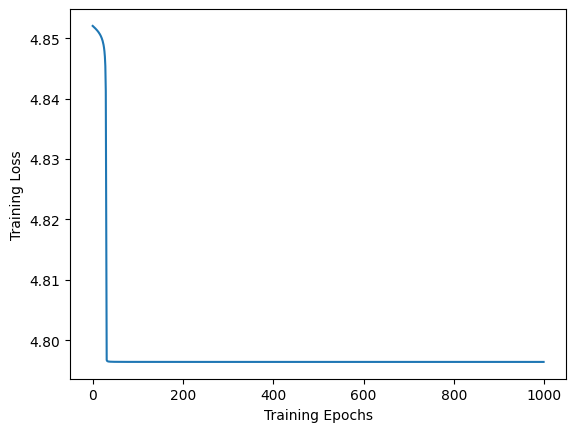

In [16]:
ax=plt.subplot()
ax.plot(losses)
ax.set_xlabel("Training Epochs")
ax.set_ylabel("Training Loss")


In [137]:
with torch.no_grad():
    #hard_model = nn.Sequential(heuristic_model.model[0:-1])
    for state, action in training_samples:
        output = heuristic_model.model(state)
        print(torch.argmax(output), torch.argmax(action))


tensor(127) tensor(7)
tensor(127) tensor(35)
tensor(127) tensor(63)
tensor(127) tensor(17)
tensor(127) tensor(4)
tensor(127) tensor(95)
tensor(127) tensor(8)
tensor(127) tensor(117)
tensor(127) tensor(87)
tensor(127) tensor(39)
tensor(127) tensor(34)
tensor(127) tensor(75)
tensor(127) tensor(99)
tensor(127) tensor(39)
tensor(127) tensor(11)
tensor(127) tensor(127)
tensor(127) tensor(63)
tensor(127) tensor(87)
tensor(127) tensor(7)
tensor(127) tensor(23)
tensor(127) tensor(1)
tensor(127) tensor(79)
tensor(127) tensor(4)
tensor(127) tensor(79)
tensor(127) tensor(47)
tensor(127) tensor(111)
tensor(127) tensor(23)
tensor(127) tensor(61)
tensor(127) tensor(19)
tensor(127) tensor(127)
tensor(127) tensor(63)
tensor(127) tensor(45)
tensor(127) tensor(83)
tensor(127) tensor(55)
tensor(127) tensor(103)
tensor(127) tensor(21)
tensor(127) tensor(31)
tensor(127) tensor(31)
tensor(127) tensor(61)
tensor(127) tensor(17)
tensor(127) tensor(79)
tensor(127) tensor(21)
tensor(127) tensor(67)
tensor(127) 